In [354]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.append(str(root / "src"))

In [355]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch
from utils import repo_root

In [356]:
ROOT = repo_root()

In [357]:
dataset = datasets.MNIST(
    root=ROOT / "data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

In [358]:
len(dataset)

60000

In [359]:
img, label = dataset[0]
print(img.shape)
print(img.dtype)
print(img.min())
print(img.max())

torch.Size([1, 28, 28])
torch.float32
tensor(0.)
tensor(1.)


In [360]:
label

5

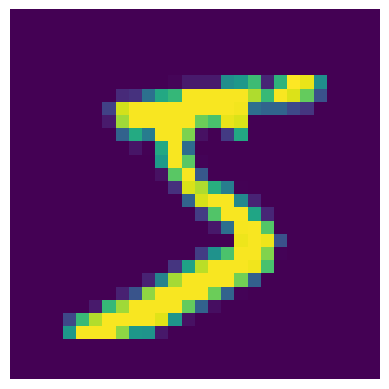

In [361]:
plt.imshow(img[0])
plt.axis('off')
plt.show()

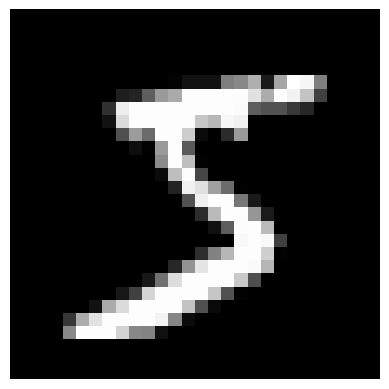

In [362]:
plt.imshow(img[0], cmap='gray')
plt.axis('off')
plt.show()

In [363]:
loader = DataLoader(dataset, batch_size=128, shuffle=True)
images, labels = next(iter(loader))
print(images.shape)
print(labels.shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


In [364]:
grid = make_grid(images[:64]) # [C, H, W]
print(grid.shape)

torch.Size([3, 242, 242])


In [365]:
try:
    plt.imshow(grid)
except Exception as e:
    plt.close()
    print(repr(e))

TypeError('Invalid shape (3, 242, 242) for image data')


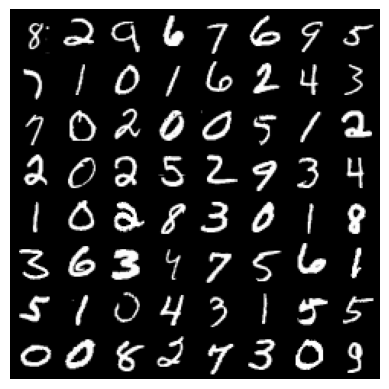

In [366]:
plt.imshow(grid.permute(1, 2, 0)) # [H, W, C]
plt.axis('off')
plt.show()

```-
nrow=8 is default
Along one axis:
8 images * 28 px = 224
9 gutters × 2 px = 18 (7 between tiles + 1 on each outer edge)
224 + 18 = 242
so row = 242, same for col, so 242 x 242
```

In [367]:
grid = make_grid(images[:64], nrow=8, padding=0) # [C, H, W]
print(grid.shape)

torch.Size([3, 224, 224])


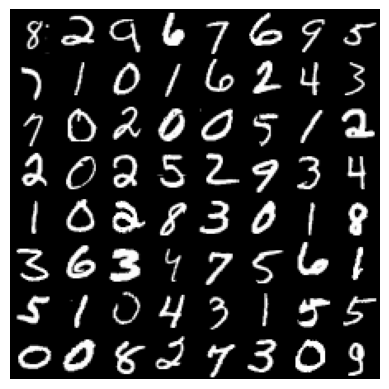

In [368]:
# notice padding on edges is reduced
plt.imshow(grid.permute(1, 2, 0)) # [H, W, C]
plt.axis('off')
plt.show()

In [369]:
# cmap="gray" was not grid, because 3 channels (RGB) are present
print(grid.shape)
# single channel from gets replicated
print(torch.all(grid[0] == grid[1]).item())
print(torch.all(grid[1] == grid[2]).item())

torch.Size([3, 224, 224])
True
True


### normalize to [-1, 1]

In [370]:
dataset = datasets.MNIST(
    root=ROOT / "data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
)

In [371]:
img, label = dataset[0]
print(img.shape)
print(img.dtype)
print(img.min())
print(img.max())

torch.Size([1, 28, 28])
torch.float32
tensor(-1.)
tensor(1.)


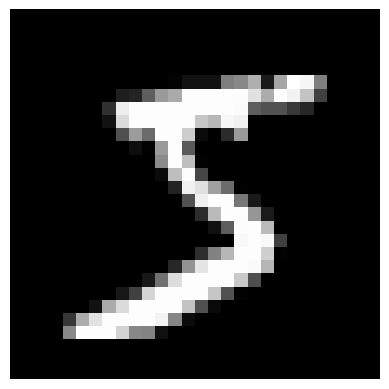

In [372]:
plt.imshow(img[0], cmap='gray')
plt.axis('off')
plt.show()

In [373]:
loader = DataLoader(dataset, batch_size=128, shuffle=True)
images, labels = next(iter(loader))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


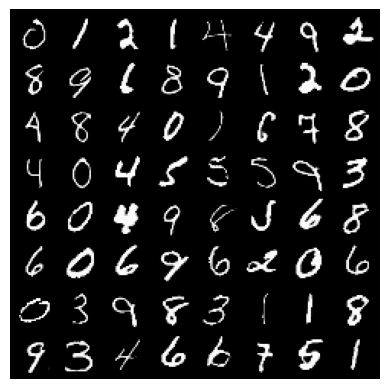

In [374]:
plt.imshow(make_grid(images[:64]).permute(1, 2, 0)) # [H, W, C]
plt.axis('off')
plt.show()

2D + cmap (cell 20): matplotlib autoscales. It maps data.min() → one end of the colormap, data.max() → the other. So [-1, 1] renders identically to [0, 1] — you can't tell from the picture that anything changed.

RGB float (cell 22): no autoscale. RGB floats are defined to be [0, 1], so matplotlib clips instead — your -1.0 background clamps to 0.0. Hence the warning.

In [375]:
print(f'[{images.min()}, {images.max()}]')
explicit = images * 0.5 + 0.5
print(f'[{explicit.min()}, {explicit.max()}]')
grid = make_grid(images[:64], normalize=True, value_range=(-1, 1))
print(f'[{grid.min()}, {grid.max()}]')

[-1.0, 1.0]
[0.0, 1.0]
[0.0, 1.0]


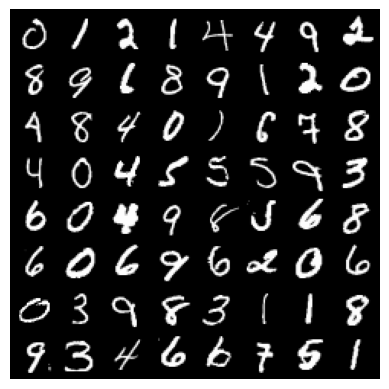

In [376]:
plt.imshow(make_grid((images * 0.5 + 0.5)[:64]).permute(1, 2, 0)) # [H, W, C]
plt.axis('off')
plt.show()

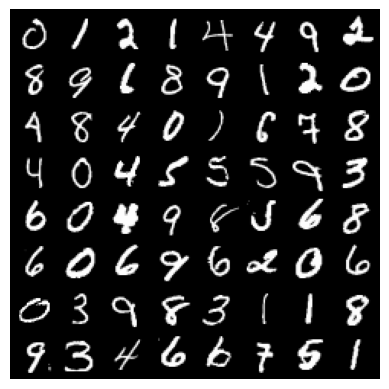

In [377]:
plt.imshow(
    make_grid(images[:64], normalize=True, value_range=(-1, 1)).permute(1, 2, 0)
)  # [H, W, C]
plt.axis('off')
plt.show()